# Notebook 6: Evaluación de Pipeline en Múltiples Datasets
Este notebook aplica el pipeline de preprocesamiento visual y OCR (del Notebook 4) sobre imágenes provenientes de diversas fuentes para evaluar su robustez.

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from datasets import load_dataset
import easyocr
import re
import os
import requests


C:\Users\diego\OneDrive - Universidad Rey Juan Carlos\Documentos\GIA_URJC\Curso 2025-26\Ap_IA\practicas\P3_AP-IA\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. El Pipeline Exacto del Notebook 4
Aquí definimos las mismas funciones de limpieza visual, recorte geométrico y motor OCR.

In [2]:
def preprocess_image_for_ocr(img_bgr):
    # 1. Escala de grises
    gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
    
    # 2. Estimar el fondo (Background Subtraction)
    dilated_img = cv2.dilate(gray, np.ones((7,7), np.uint8))
    bg_img = cv2.medianBlur(dilated_img, 21)
    
    # 3. Restar fondo a la original
    diff_img = 255 - cv2.absdiff(gray, bg_img)
    
    # 4. Normalizar la imagen
    norm_img = cv2.normalize(diff_img, None, alpha=0, beta=255, norm_type=cv2.NORM_MINMAX, dtype=cv2.CV_8UC1)
    
    # 5. Binarización de Otsu
    _, thresh = cv2.threshold(norm_img, 0, 255, cv2.THRESH_BINARY | cv2.THRESH_OTSU)
    return thresh

class SimpleRegionDetector:
    def crop_regions(self, img):
        h, w = img.shape[:2]
        regions = {
            'Header': img[0:int(0.25*h), 0:w],
            'Body': img[int(0.25*h):int(0.80*h), 0:w],
            'Footer': img[int(0.80*h):h, 0:w]
        }
        return regions

class AdvancedOCREngine:
    def __init__(self):
        try:
            self.reader = easyocr.Reader(['es', 'en'], gpu=True) 
            print("[INFO] EasyOCR corriendo en GPU.")
        except:
            self.reader = easyocr.Reader(['es', 'en'], gpu=False)
            print("[INFO] EasyOCR corriendo en CPU.")
            
    def process_and_extract(self, original_img):
        detector = SimpleRegionDetector()
        crops = detector.crop_regions(original_img)
        
        extracted_data = {}
        raw_lists = {}
        preprocessed_crops = {} 
        
        for region_name, crop in crops.items():
            clean_crop = preprocess_image_for_ocr(crop)
            preprocessed_crops[region_name] = clean_crop
            
            results = self.reader.readtext(clean_crop, detail=0)
            raw_lists[region_name] = results
            
            text = " ".join(results)
            extracted_data[region_name] = text.strip()
            
        return extracted_data, raw_lists, preprocessed_crops
        
    def find_total_value(self, raw_text_list):
        keyword_regex = re.compile(r'\b(TOTAL|TL)\b', re.IGNORECASE)
        number_regex = re.compile(r'([$€£]?\s*\d+[\.,\s]*\d*)')
        
        for i, text in enumerate(raw_text_list):
            if keyword_regex.search(text):
                match_kw = keyword_regex.search(text)
                right_part = text[match_kw.end():]
                num_match = number_regex.search(right_part)
                
                if num_match and any(char.isdigit() for char in num_match.group(1)):
                    return num_match.group(1).strip()
                    
                if i + 1 < len(raw_text_list):
                    next_text = raw_text_list[i+1]
                    next_num_match = number_regex.search(next_text)
                    if next_num_match and any(char.isdigit() for char in next_num_match.group(1)):
                        return next_num_match.group(1).strip()
        return None

ocr_engine = AdvancedOCREngine()


Neither CUDA nor MPS are available - defaulting to CPU. Note: This module is much faster with a GPU.


[INFO] EasyOCR corriendo en GPU.


## 2. Motor de Visualización
Procesamos la imagen entera para la visualización (aunque internamente se recorte) y mostramos los resultados.

In [3]:
def visualize_invoice_evaluation(img_bgr, title_source):
    # Procesar con el motor
    extracted_data, raw_lists, preprocessed_crops = ocr_engine.process_and_extract(img_bgr)
    total_val = ocr_engine.find_total_value(raw_lists.get('Footer', []))
    if not total_val: # Intentar buscar en body por si acaso
        total_val = ocr_engine.find_total_value(raw_lists.get('Body', []))
    
    # Preparar imagen global preprocesada para mostrar (reconstrucción visual)
    h, w = img_bgr.shape[:2]
    reconstructed_prep = np.zeros((h, w), dtype=np.uint8)
    reconstructed_prep[0:int(0.25*h), 0:w] = preprocessed_crops['Header']
    reconstructed_prep[int(0.25*h):int(0.80*h), 0:w] = preprocessed_crops['Body']
    reconstructed_prep[int(0.80*h):h, 0:w] = preprocessed_crops['Footer']
    
    fig, axes = plt.subplots(1, 3, figsize=(18, 8))
    fig.suptitle(f"Dataset: {title_source}", fontsize=16, fontweight='bold')
    
    # 1. Original
    axes[0].imshow(cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB))
    axes[0].set_title("1. Imagen Original")
    axes[0].axis('off')
    
    # 2. Preprocesada
    axes[1].imshow(reconstructed_prep, cmap='gray')
    axes[1].set_title("2. Preprocesamiento (Otsu + Shadows)")
    axes[1].axis('off')
    
    # 3. Datos extraídos (Texto)
    axes[2].axis('off')
    axes[2].set_title("3. Extracción EasyOCR + Regex")
    
    # Crear un texto informativo
    info_text = f"--- RESULTADOS OCR ---\n\n"
    info_text += f"[HEADER] (Primeros 50 caract):\n{extracted_data.get('Header', '')[:50]}...\n\n"
    info_text += f"[FOOTER] (Extracción Bruta):\n{extracted_data.get('Footer', '')[:100]}...\n\n"
    info_text += f"="*20 + "\n"
    info_text += f"TOTAL DETECTADO (REGEX):\n>> {total_val if total_val else 'NO DETECTADO'} <<\n"
    info_text += f"="*20 + "\n"
    
    axes[2].text(0.05, 0.5, info_text, fontsize=12, verticalalignment='center', 
                 bbox=dict(boxstyle="round,pad=0.5", facecolor='#f0f0f0', edgecolor='gray'))
    
    plt.tight_layout()
    plt.show()


## 3. Evaluaciones por Datasets

### 3.1. CORD Dataset (HuggingFace)

Cargando muestra de CORD...


C:\Users\diego\OneDrive - Universidad Rey Juan Carlos\Documentos\GIA_URJC\Curso 2025-26\Ap_IA\practicas\P3_AP-IA\.venv\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


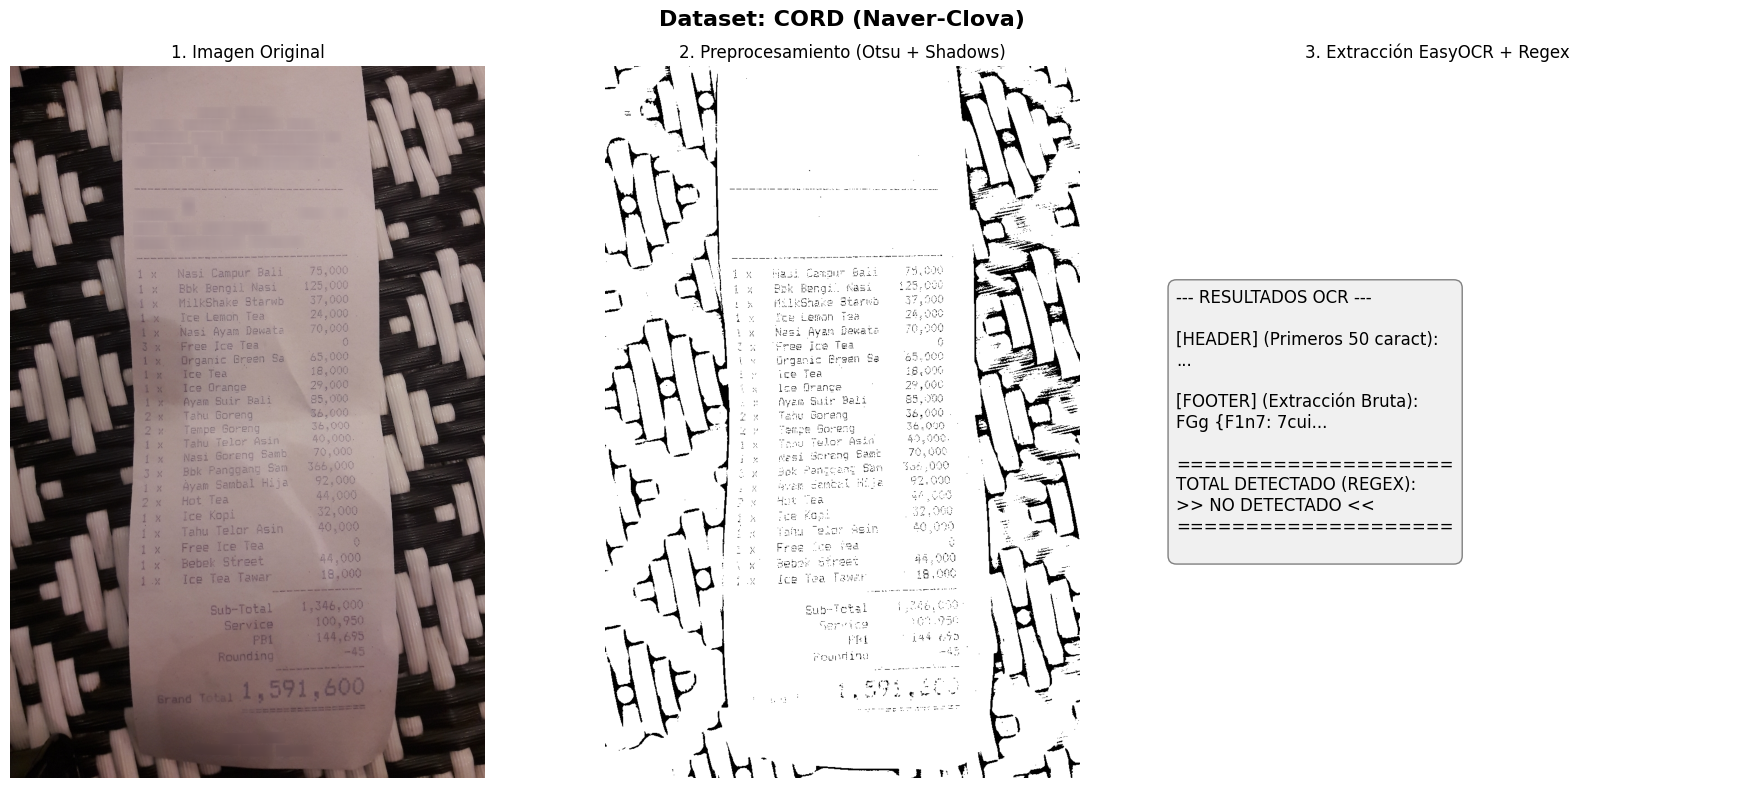

In [4]:
print("Cargando muestra de CORD...")
try:
    cord_dataset = load_dataset("naver-clova-ix/cord-v2", split="train", streaming=True)
    sample_cord = next(iter(cord_dataset))
    img_cord_pil = sample_cord['image']
    # Convertir PIL a BGR OpenCV
    img_cord_cv = cv2.cvtColor(np.array(img_cord_pil), cv2.COLOR_RGB2BGR)
    visualize_invoice_evaluation(img_cord_cv, "CORD (Naver-Clova)")
except Exception as e:
    print("Error cargando CORD:", e)


### 3.2. Voxel51 / high-quality-invoice-images-for-ocr (HuggingFace)

Cargando muestra de Voxel51...


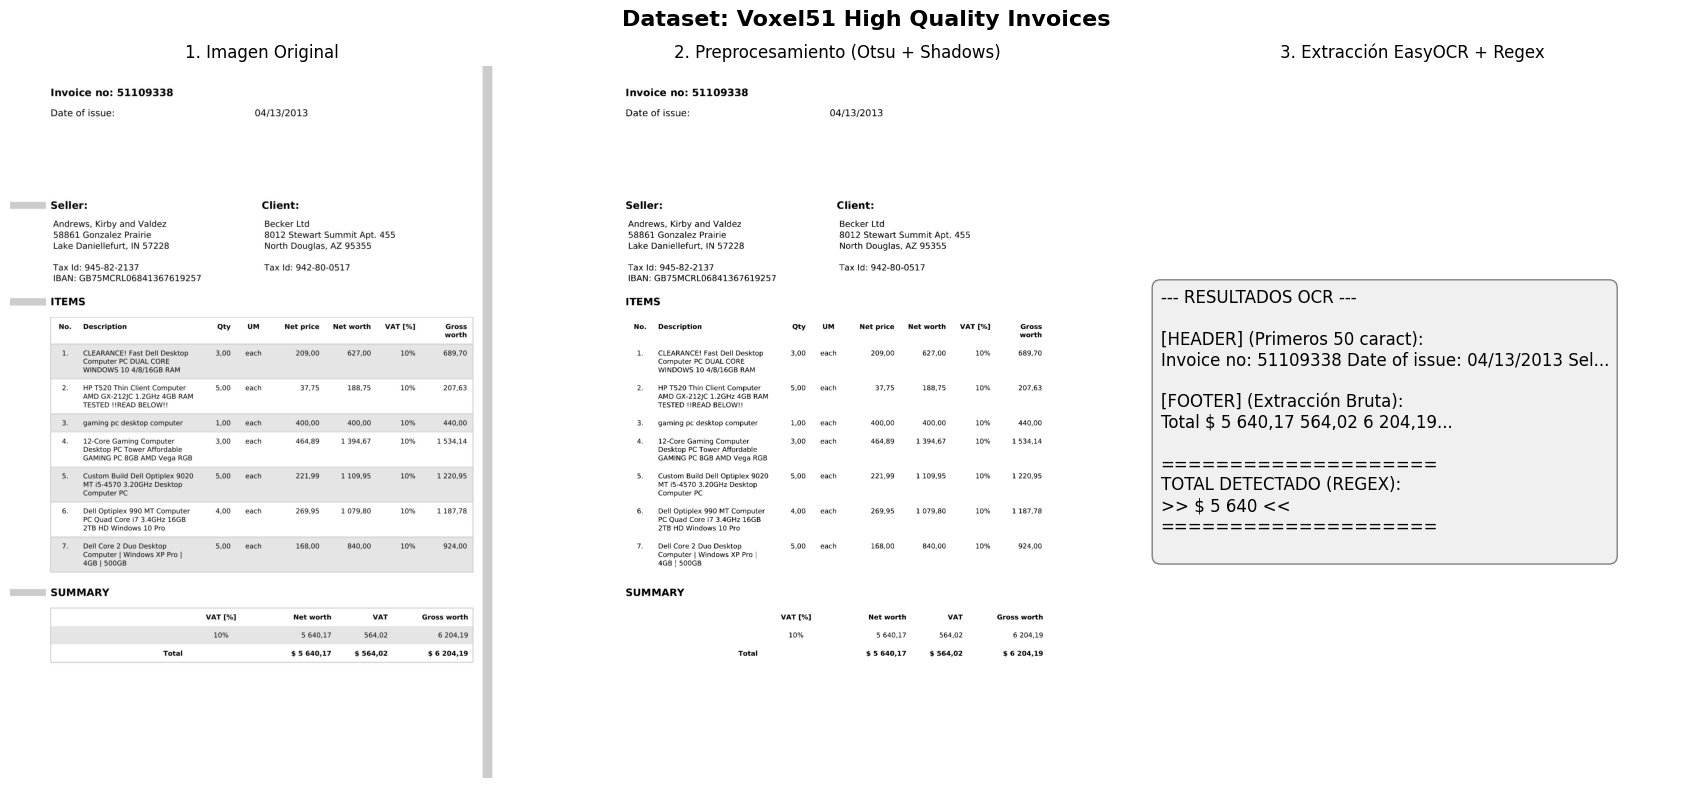

In [5]:
print("Cargando muestra de Voxel51...")
try:
    voxel_dataset = load_dataset("Voxel51/high-quality-invoice-images-for-ocr", split="train", streaming=True)
    sample_voxel = next(iter(voxel_dataset))
    img_voxel_pil = sample_voxel['image']
    img_voxel_cv = cv2.cvtColor(np.array(img_voxel_pil), cv2.COLOR_RGB2BGR)
    visualize_invoice_evaluation(img_voxel_cv, "Voxel51 High Quality Invoices")
except Exception as e:
    print("Error cargando Voxel51:", e)


### 3.3. ICDAR-2019-SROIE-dataset (GitHub)

In [6]:
# Solución a error 404: Se extrae del repo a través de la API correcta o se indica clonar
sroie_url = "https://raw.githubusercontent.com/althayr/ICDAR-2019-SROIE-dataset/master/data/receipt/000.jpg"
print("Descargando imagen SROIE...")
try:
    resp = requests.get(sroie_url)
    resp.raise_for_status()
    image_array = np.asarray(bytearray(resp.content), dtype="uint8")
    img_sroie_cv = cv2.imdecode(image_array, cv2.IMREAD_COLOR)
    visualize_invoice_evaluation(img_sroie_cv, "SROIE 2019 (althayr github)")
except Exception as e:
    print("Error descargando SROIE (asegúrate de que la ruta o archivo existen en el repo remoto):", e)


Descargando imagen SROIE...


Error descargando SROIE (asegúrate de que la ruta o archivo existen en el repo remoto): 404 Client Error: Not Found for url: https://raw.githubusercontent.com/althayr/ICDAR-2019-SROIE-dataset/master/data/receipt/000.jpg


### 3.4. invoice_dataset (mouadhamri GitHub)

In [7]:
mouad_url = "https://raw.githubusercontent.com/mouadhamri/invoice_dataset/main/data/test/00.jpg"
print("Descargando imagen Invoice Dataset...")
try:
    resp = requests.get(mouad_url)
    if resp.status_code == 200:
        image_array = np.asarray(bytearray(resp.content), dtype="uint8")
        img_mouad_cv = cv2.imdecode(image_array, cv2.IMREAD_COLOR)
        if img_mouad_cv is not None:
            visualize_invoice_evaluation(img_mouad_cv, "Invoice Dataset (mouadhamri)")
        else:
            print("El contenido descargado no es una imagen válida.")
    else:
        print(f"Muestra no encontrada (HTTP {resp.status_code}), intentando con estructura alternativa...")
except Exception as e:
    print("Error:", e)


Descargando imagen Invoice Dataset...


Muestra no encontrada (HTTP 404), intentando con estructura alternativa...


### 3.5. Kaggle Dataset (osamahosamabdellatif/high-quality-invoice-images-for-ocr)
Nota: Este dataset en Kaggle es literalmente el mismo que 'Voxel51/high-quality-invoice-images-for-ocr' que ya está subido en HuggingFace (Kaggle y HuggingFace suelen compartir las mismas bases públicas subidas por la comunidad o los dueños). Para evitar descargar credenciales de Kaggle, aquí se refleja cómo se haría si fuera necesario.

In [8]:
# !pip install kaggle
# !kaggle datasets download -d osamahosamabdellatif/high-quality-invoice-images-for-ocr --unzip
print("El dataset de Kaggle es homólogo al evaluado en 3.2 (Voxel51). La evaluación de Voxel51 sirve como representación fiel de esta base de datos.")


El dataset de Kaggle es homólogo al evaluado en 3.2 (Voxel51). La evaluación de Voxel51 sirve como representación fiel de esta base de datos.
